In [1]:
!pip install langchain-openai
!pip install langchain-community
!pip install -U ddgs

In [2]:
import os
from google.colab import userdata
from langchain_openai import ChatOpenAI

os.environ['OPENAI_API_KEY'] = "OPENAI_API_KEY"
llm = ChatOpenAI(model="gpt-4o")

In [3]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

In [6]:
# search tools
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

search.invoke("How old is Brad Pitt?")

'4 days ago -William Bradley Pitt (born December 18, 1963) is an American actor and film producer. In a film career spanning more than thirty years, Pitt has received numerous accolades, including two Academy Awards, two British Academy Film Awards, two Golden Globe Awards, two Primetime Emmy Awards and ... August 14, 2025 -William Bradley "Brad" Pitt (born December 18, 1963) is an Academy Award-winning American actor and Movie producer. William Bradley Pitt was born in Shawnee, Oklahoma, to Jane Etta (née Hillhouse), a school counsellor, and William Alvin Pitt, ... February 24, 2026 -William Bradley "Brad" Pitt wasborn on December 18, 1963in Shawnee, Oklahoma and raised in Springfield, Missouri, the son of Jane Etta (Hillhouse), a school counselor, and William Alvin "Bill" Pitt, a truck company manager. December 18, 2025 -Brad Pitt marked his62nd birthdayon Thursday, Dec. 1 month ago -Brad Pitt (born December 18, 1963, Shawnee, Oklahoma, U.S.) is an American actor known for his portra

In [7]:
tools = [add, multiply, divide, search]

llm_with_tools = llm.bind_tools(tools)

In [8]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs.")

In [9]:
# Node
def reasoner(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

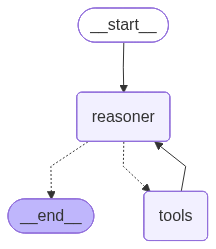

In [10]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition # this is the checker for the if you got a tool back
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Add nodes
builder.add_node("reasoner", reasoner)
builder.add_node("tools", ToolNode(tools)) # for the tools

# Add edges
builder.add_edge(START, "reasoner")
builder.add_conditional_edges(
    "reasoner",
    # If the latest message (result) from node reasoner is a tool call -> tools_condition routes to tools
    # If the latest message (result) from node reasoner is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "reasoner")
react_graph = builder.compile()

# Display the graph
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [11]:
messages = [HumanMessage(content="What is 2 times Brad Pitt's age?")]
messages = react_graph.invoke({"messages": messages})

In [12]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 times Brad Pitt's age?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_q7uZRGbWQ6drsQfgAASoxmSY)
 Call ID: call_q7uZRGbWQ6drsQfgAASoxmSY
  Args:
    query: Brad Pitt age 2023
================================= Tool Message =================================
Name: duckduckgo_search

BradPittmarked his 62nd birthday on Thursday, Dec. 18 The actor is "doing well" and he's "excited" about his future with girlfriend Ines de Ramon, a source tells PEOPLE "She's perfect for him. BradPittEarly life, Education, Career, Awards, Achievements, Controversy, Unknown Facts About (Profile/Biography): William BradleyPitt, known worldwide asBradPitt, is an American actor and film producer who has captivated audiences for over three decades. BradPittis an American actor known for his portrayal of unconventional characters. He channeled his magneti